## Pengelompokan Tingkat Keparahan Luka Diabetes dari Citra Kaki Menggunakan CNN dan K-Means


## Setup Google Colab

Cell di bawah hanya aktif jika notebook ini dibuka di Google Colab. Jika dijalankan di lokal, cell ini tidak akan melakukan apa-apa.

In [2]:
import importlib.util

IN_COLAB = importlib.util.find_spec("google.colab") is not None

if IN_COLAB:
    from pathlib import Path

    REPO_URL = "https://github.com/musyaree/fp-kcv.git"
    REPO_DIR = Path("/content/fp-kcv")

    if not REPO_DIR.exists():
        !git clone {REPO_URL} {REPO_DIR}

    %cd {REPO_DIR}/notebook

    raw_dir = REPO_DIR / "data" / "raw"
    if not raw_dir.exists() or not any(raw_dir.iterdir()):
        !python ../download_data.py
else:
    print("Bukan di Colab, lewati setup Colab.")

Bukan di Colab, lewati setup Colab.


## Tahap 0. Setup

In [4]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(REPO_ROOT / "src"))

from data_prep import eda, preprocess, split_dataset, subset_dataset

## Tahap 1. Pengumpulan dan Eksplorasi Dataset (EDA)

### 1.1 Mengunduh Dataset & Mengambil Subset

Dataset, Diabetic Foot Ulcer, diunduh terpisah dengan menjalankan `download_data.py`. Kita mengambil subset seimbang, yaitu 250 Abnormal dan 250 Normal, dari folder `Patches/` yang sudah berlabel.

In [6]:
subset_dataset.main(argv=[])

Abnormal: 250 gambar disalin ke data\processed\subset\Abnormal
Normal: 250 gambar disalin ke data\processed\subset\Normal

Total: 500 gambar. Manifest disimpan di data\processed\subset\manifest.csv


### 1.2 Eksplorasi Data (EDA)

Cek jumlah gambar per kategori, lihat statistik ukurannya, lalu tampilkan beberapa sampel visual agar variasi data terlihat.

=== EDA Summary — Subset DFU ===

Jumlah gambar per kategori:
  Abnormal: 250
  Normal: 250
  Total: 500

Statistik ukuran gambar:
  Width  : min=220, max=330
  Height : min=220, max=330
  Ukuran unik: [(220, 220), (224, 224), (224, 244), (227, 227), (283, 280), (304, 294), (310, 316), (330, 330)]

Sampel visual disimpan di: outputs\eda_sample_grid.png
Sumber dataset: Kaggle Diabetic Foot Ulcer (DFU) Dataset (Laith Jj)
https://www.kaggle.com/datasets/laithjj/diabetic-foot-ulcer-dfu

Grid sampel disimpan di: outputs\eda_sample_grid.png


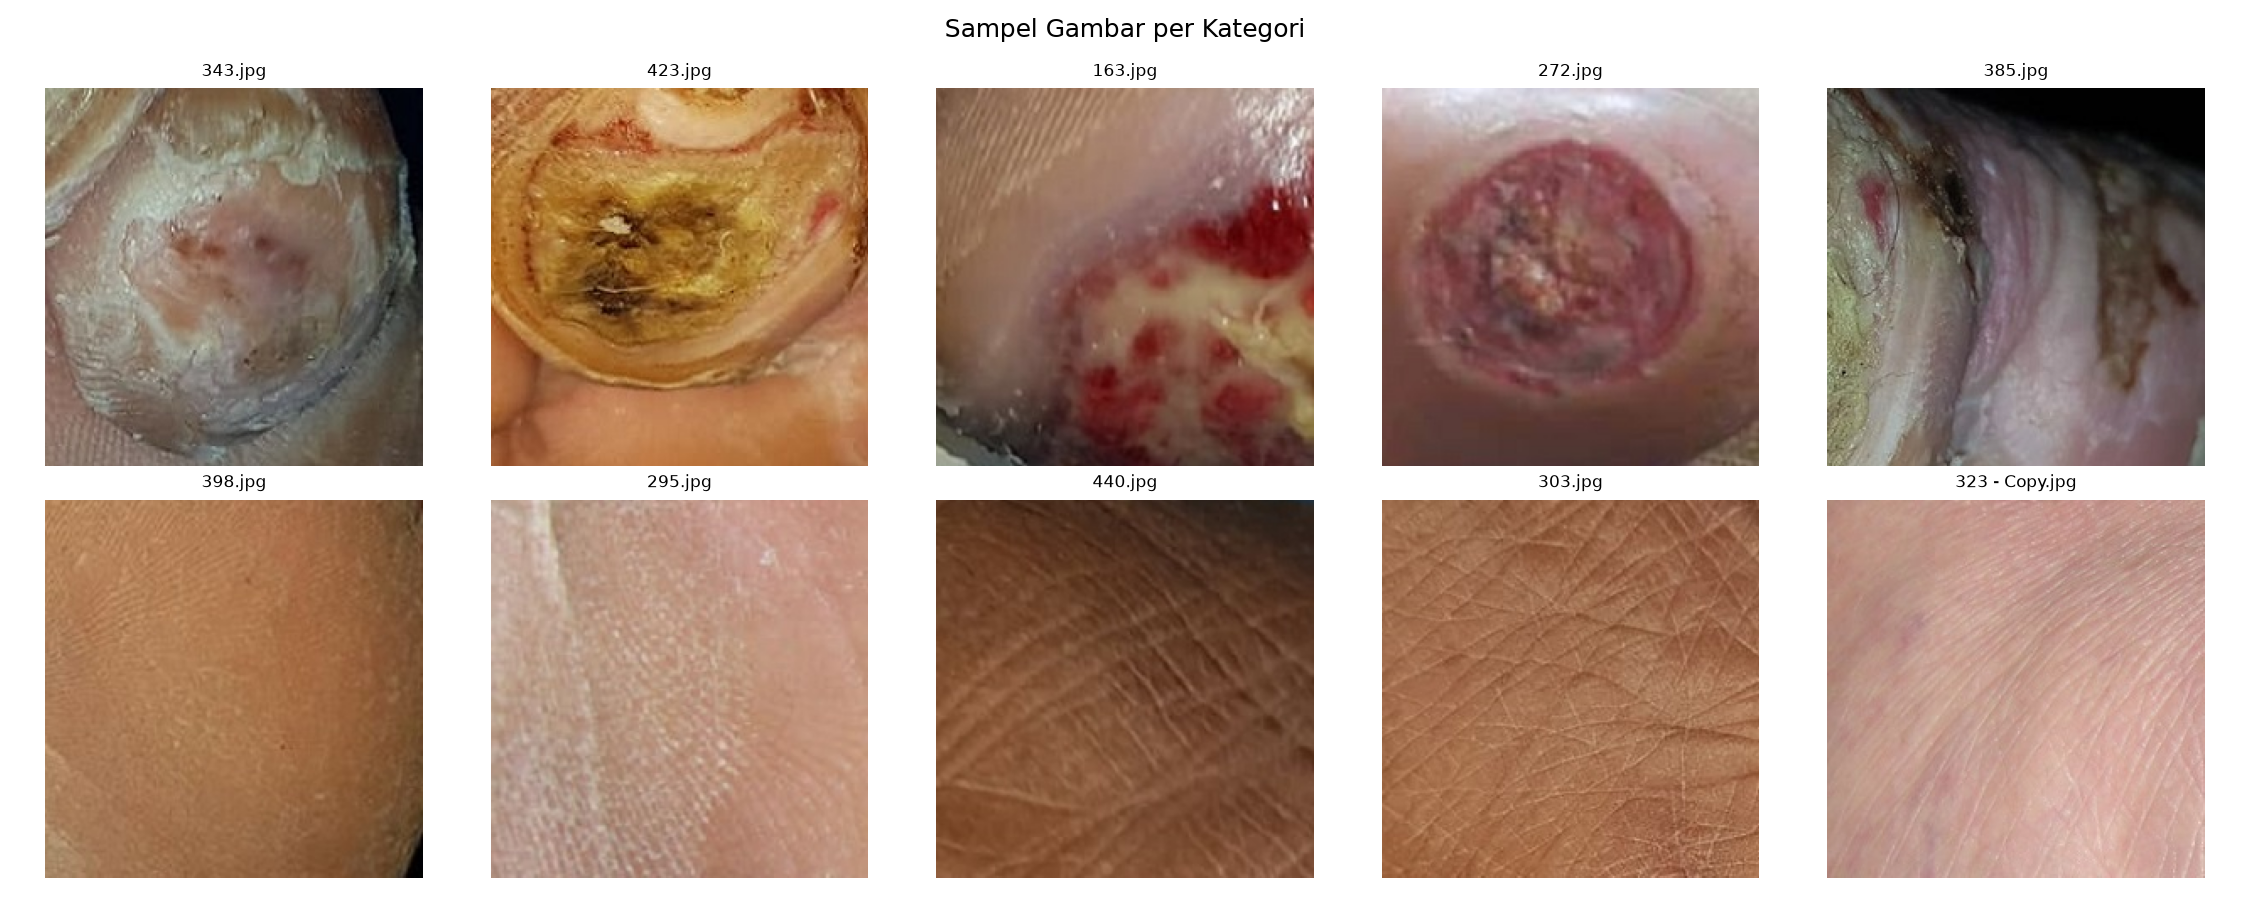

In [7]:
from IPython.display import Image, display

eda.main()
display(Image(filename=str(eda.OUTPUTS_DIR / "eda_sample_grid.png")))

## Tahap 2. Pra-pemrosesan Citra

### 2.1 Standardisasi Ukuran, Format, dan Normalisasi

Pre-Process CNN: resize semua gambar ke ukuran 224x224, lalu normalisasi memakai mean/std ImageNet.
Pre-Process Handcrafted: Konversi ke HSV menggunakan skala 0-1.

In [8]:
preprocess.main()

Selesai preprocessing.


### 2.2 Split Data Latih dan Data Uji

Split 80:20 per kategori, supaya proporsi Normal dan Abnormal tetap seimbang di kedua sisi.

In [9]:
split_dataset.main()

Selesai split data.


In [10]:
import csv

import pandas as pd

with open(split_dataset.MANIFEST_PATH, newline="", encoding="utf-8") as f:
    rows = list(csv.DictReader(f))

df = pd.DataFrame(rows)
pd.crosstab(df["label"], df["split"])

split,test,train
label,,
Abnormal,50,200
Normal,50,200


### 2.3 Tahap Ekstraksi Fitur CNN

Setiap gambar yang sudah dipreproses (ukuran 224x224, ternormalisasi) diteruskan ke CNN pretrained ResNet50, tanpa layer klasifikasi di ujungnya. Hasil keluaran layer terakhir sebelum klasifikasi berupa vektor 2048 angka per gambar, disebut embedding atau fitur. Vektor ini merepresentasikan pola visual gambar (tekstur, bentuk, warna) dalam bentuk numerik, dan nantinya jadi input untuk clustering K-Means di Tahap 3. CNN di sini cuma dipakai sebagai ekstraktor fitur, bobotnya sudah dilatih sebelumnya di dataset ImageNet dan tidak dilatih ulang.

In [11]:
import feature_extraction

feature_extraction.main()

Data latih: 400, Data uji: 100
Ekstraksi fitur data latih...
  16/400 gambar diproses
  32/400 gambar diproses
  48/400 gambar diproses
  64/400 gambar diproses
  80/400 gambar diproses
  96/400 gambar diproses
  112/400 gambar diproses
  128/400 gambar diproses
  144/400 gambar diproses
  160/400 gambar diproses
  176/400 gambar diproses
  192/400 gambar diproses
  208/400 gambar diproses
  224/400 gambar diproses
  240/400 gambar diproses
  256/400 gambar diproses
  272/400 gambar diproses
  288/400 gambar diproses
  304/400 gambar diproses
  320/400 gambar diproses
  336/400 gambar diproses
  352/400 gambar diproses
  368/400 gambar diproses
  384/400 gambar diproses
  400/400 gambar diproses
Ekstraksi fitur data uji...
  16/100 gambar diproses
  32/100 gambar diproses
  48/100 gambar diproses
  64/100 gambar diproses
  80/100 gambar diproses
  96/100 gambar diproses
  100/100 gambar diproses
Selesai. X_train: (400, 2048), X_test: (100, 2048)


In [12]:
import numpy as np

X_train = np.load(feature_extraction.OUTPUTS_DIR / "features_cnn_train.npy")
X_test = np.load(feature_extraction.OUTPUTS_DIR / "features_cnn_test.npy")
y_train = np.load(feature_extraction.OUTPUTS_DIR / "labels_train.npy", allow_pickle=True)
y_test = np.load(feature_extraction.OUTPUTS_DIR / "labels_test.npy", allow_pickle=True)

print("Fitur data latih:", X_train.shape)
print("Fitur data uji:", X_test.shape)
print("Contoh 5 angka pertama dari fitur gambar pertama:", X_train[0][:5])
print("Label unik:", np.unique(y_train))

Fitur data latih: (400, 2048)
Fitur data uji: (100, 2048)
Contoh 5 angka pertama dari fitur gambar pertama: [0.02726319 0.309842   0.         0.         0.00633577]
Label unik: ['Abnormal' 'Normal']


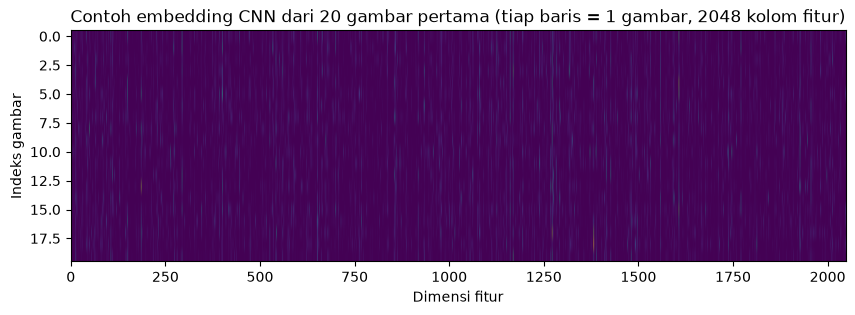

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3))
ax.imshow(X_train[:20], aspect="auto", cmap="viridis")
ax.set_title("Contoh embedding CNN dari 20 gambar pertama (tiap baris = 1 gambar, 2048 kolom fitur)")
ax.set_xlabel("Dimensi fitur")
ax.set_ylabel("Indeks gambar")
plt.show()

### 2.4 Ekstraksi Fitur Handcrafted (Warna)

Sebagai pembanding CNN embedding di Skenario 2, dihitung fitur warna sederhana dari citra HSV: rata-rata (mean) dan standar deviasi tiap channel (H, S, V). Kombinasi mean dan standar deviasi ini disebut color moments, totalnya 6 angka per gambar. Fitur ini jauh lebih sederhana dari embedding CNN (2048 dimensi), tujuannya untuk melihat apakah fitur dari deep learning benar-benar memberi nilai tambah dibanding fitur warna biasa.

In [14]:
import feature_extraction_handcrafted

feature_extraction_handcrafted.main()

Data latih: 400, Data uji: 100
Ekstraksi fitur handcrafted data latih...
  50/400 gambar diproses
  100/400 gambar diproses
  150/400 gambar diproses
  200/400 gambar diproses
  250/400 gambar diproses
  300/400 gambar diproses
  350/400 gambar diproses
  400/400 gambar diproses
Ekstraksi fitur handcrafted data uji...
  50/100 gambar diproses
  100/100 gambar diproses
Selesai. X_train: (400, 6), X_test: (100, 6)


In [15]:
X_train_hc = np.load(feature_extraction_handcrafted.OUTPUTS_DIR / "features_handcrafted_train.npy")
X_test_hc = np.load(feature_extraction_handcrafted.OUTPUTS_DIR / "features_handcrafted_test.npy")

print("Fitur handcrafted data latih:", X_train_hc.shape)
print("Fitur handcrafted data uji:", X_test_hc.shape)
print("Contoh fitur gambar pertama [mean_H, std_H, mean_S, std_S, mean_V, std_V]:", X_train_hc[0])

Fitur handcrafted data latih: (400, 6)
Fitur handcrafted data uji: (100, 6)
Contoh fitur gambar pertama [mean_H, std_H, mean_S, std_S, mean_V, std_V]: [0.13740098 0.09776728 0.18789422 0.1121311  0.56094328 0.12258385]


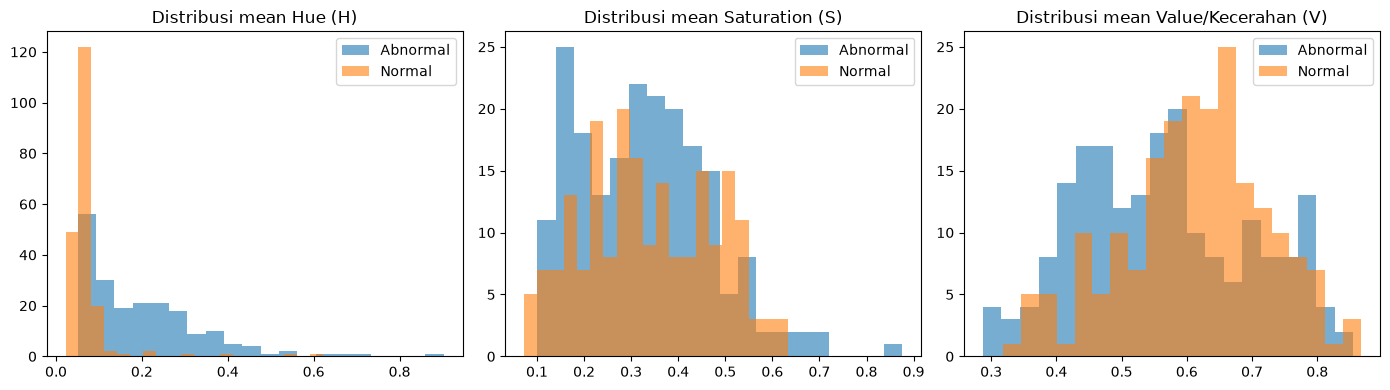

In [16]:
# bandingin distribusi warna abnormal vs normal
y_train_arr = np.array([r["label"] for r in feature_extraction_handcrafted.load_manifest() if r["split"] == "train"])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
nama_channel = ["Hue (H)", "Saturation (S)", "Value/Kecerahan (V)"]

for i, ax in enumerate(axes):
    idx_kolom = i * 2  # kolom mean tiap channel ada di index 0, 2, 4
    ax.hist(X_train_hc[y_train_arr == "Abnormal", idx_kolom], bins=20, alpha=0.6, label="Abnormal")
    ax.hist(X_train_hc[y_train_arr == "Normal", idx_kolom], bins=20, alpha=0.6, label="Normal")
    ax.set_title(f"Distribusi mean {nama_channel[i]}")
    ax.legend()

plt.tight_layout()
plt.show()

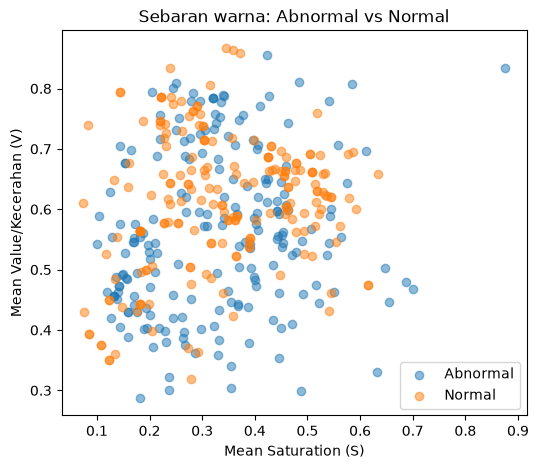

In [17]:
# scatter saturasi vs kecerahan, per kelas
plt.figure(figsize=(6, 5))
plt.scatter(X_train_hc[y_train_arr == "Abnormal", 2], X_train_hc[y_train_arr == "Abnormal", 4], alpha=0.5, label="Abnormal")
plt.scatter(X_train_hc[y_train_arr == "Normal", 2], X_train_hc[y_train_arr == "Normal", 4], alpha=0.5, label="Normal")
plt.xlabel("Mean Saturation (S)")
plt.ylabel("Mean Value/Kecerahan (V)")
plt.title("Sebaran warna: Abnormal vs Normal")
plt.legend()
plt.show()

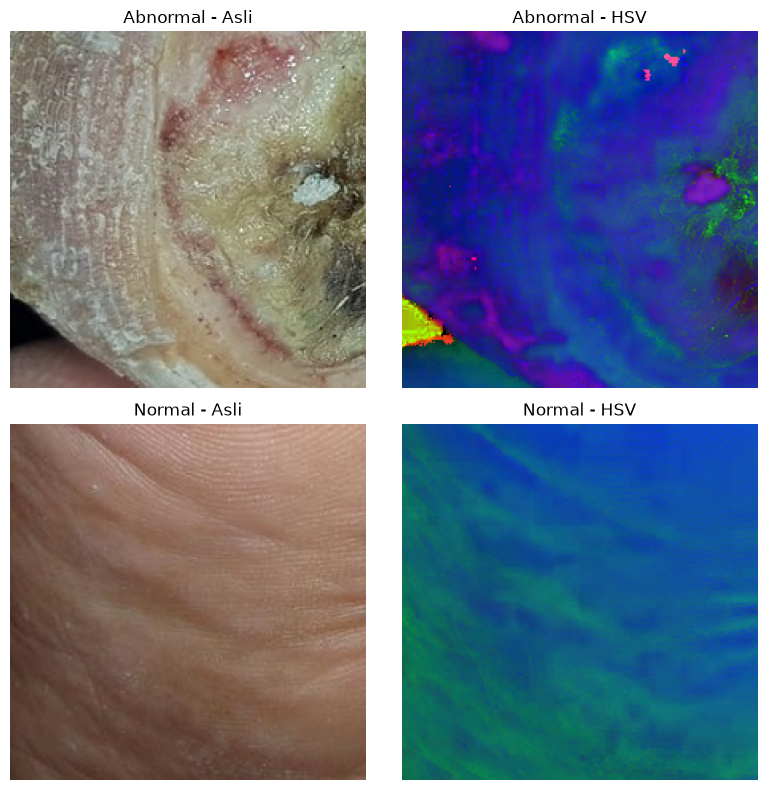

In [18]:
# bandingin gambar asli vs HSV, 1 contoh abnormal 1 contoh normal
from PIL import Image
import random

manifest_rows = feature_extraction_handcrafted.load_manifest()
contoh_abnormal = next(r for r in manifest_rows if r["label"] == "Abnormal" and r["split"] == "train")
contoh_normal = next(r for r in manifest_rows if r["label"] == "Normal" and r["split"] == "train")

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for i, contoh in enumerate([contoh_abnormal, contoh_normal]):
    img_asli = Image.open(feature_extraction_handcrafted.SUBSET_DIR / contoh["label"] / contoh["filename"])
    arr_hsv = np.load(feature_extraction_handcrafted.PREPROCESSED_DIR / "hsv_normalized" / contoh["label"] / Path(contoh["filename"]).with_suffix(".npy"))

    axes[i, 0].imshow(img_asli)
    axes[i, 0].set_title(f"{contoh['label']} - Asli")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(arr_hsv)
    axes[i, 1].set_title(f"{contoh['label']} - HSV")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()